In [69]:
import numpy as np
import polars as pl
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 16

# 2.A : Few trajectories + Mean + Theory (Homogeneous)

In [70]:
# --- Load files --- #
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/2026-03-09__PC/nucleo__fig2_0")
paths = [str(p) for p in root.glob("*/**/*.parquet")] or [str(p) for p in root.glob("*/*.parquet")]
df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algorithm", "fact", "factmode",
        "landscape", "s", "l", "lmbda", "alphar"
        ])
)

df_one = df_all.filter(pl.col("landscape") == "homogeneous")
thetas = np.unique(df_one["theta"].to_numpy())


# --- Figure --- #
for idx, theta_val in enumerate(thetas[:]):

    # --- Data ---
    df_theta = df_one.filter(pl.col("theta") == theta_val)
    trajs = df_theta["results"][0].to_numpy()
    mean_traj = df_theta["results_mean"][0].to_numpy()
    v_mean_th = df_theta["v_mean_th"].to_numpy()
    times = df_theta["times"][0].to_numpy()
    mu = df_theta["mu"].to_numpy()

    # --- Figure ---
    plt.figure(figsize=(8,6), dpi=1200)

    # Trajectoires individuelles
    plt.plot(trajs[0], drawstyle="steps-post",
             color="red", alpha=0.30, label="trajectories")
    for i in range(1, 10):
        plt.plot(trajs[i], drawstyle="steps-post",
                 color="red", alpha=0.30)

    # Moyenne simulée
    plt.plot(mean_traj,
             color="red", ls="-", lw=2,
             label=r"$v_{mean}$")

    # Vitesse homogène théorique
    plt.scatter(times, times*v_mean_th,
                color="black", lw=2,
                label=r"$v_{homogeneous}$",
                marker="+")

    # Mise en forme
    plt.ylim([-100, 2100])
    plt.grid(True, alpha=0.3)
    plt.title(f"(μ,θ) = ({mu[0]},{theta_val})")
    plt.xlabel(r"Time ($1/k_0$)")
    plt.ylabel("Position")
    plt.legend()

    plt.tight_layout()
    plt.show()

[1.000e-01 1.100e+00 2.100e+00 3.100e+00 4.100e+00 5.100e+00 6.100e+00
 7.100e+00 8.100e+00 9.100e+00 1.010e+01 1.110e+01 1.210e+01 1.310e+01
 1.410e+01 1.510e+01 1.610e+01 1.710e+01 1.810e+01 1.910e+01 2.010e+01
 2.110e+01 2.210e+01 2.310e+01 2.410e+01 2.510e+01 2.610e+01 2.710e+01
 2.810e+01 2.910e+01 3.010e+01 3.110e+01 3.210e+01 3.310e+01 3.410e+01
 3.510e+01 3.610e+01 3.710e+01 3.810e+01 3.910e+01 4.010e+01 4.110e+01
 4.210e+01 4.310e+01 4.410e+01 4.510e+01 4.610e+01 4.710e+01 4.810e+01
 4.910e+01 5.010e+01 5.110e+01 5.210e+01 5.310e+01 5.410e+01 5.510e+01
 5.610e+01 5.710e+01 5.810e+01 5.910e+01 6.010e+01 6.110e+01 6.210e+01
 6.310e+01 6.410e+01 6.510e+01 6.610e+01 6.710e+01 6.810e+01 6.910e+01
 7.010e+01 7.110e+01 7.210e+01 7.310e+01 7.410e+01 7.510e+01 7.610e+01
 7.710e+01 7.810e+01 7.910e+01 8.010e+01 8.110e+01 8.210e+01 8.310e+01
 8.410e+01 8.510e+01 8.610e+01 8.710e+01 8.810e+01 8.910e+01 9.010e+01
 9.110e+01 9.210e+01 9.310e+01 9.410e+01 9.510e+01 9.610e+01 9.710e+01
 9.810

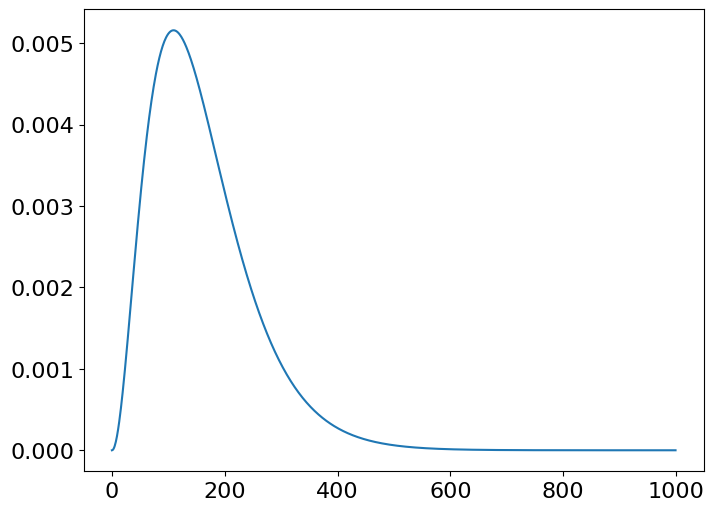

1.0


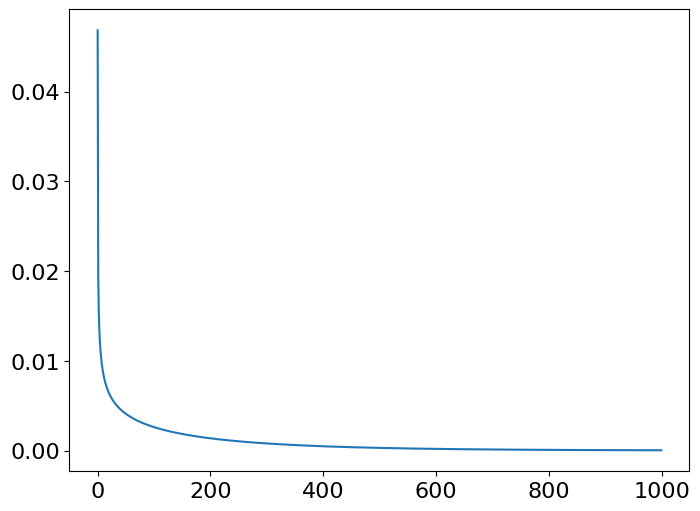

In [71]:
from nucleo.simulation.probabilities import proba_gamma

L = np.arange(0.1, 1000 + 0.1, 1)
print(L)

p = proba_gamma(mu = 160, theta = 90, L = L)
print(np.sum(p))
plt.figure(figsize=(8,6))
plt.plot(L, p)
plt.show()

p = proba_gamma(mu = 160, theta = 200, L = L)
print(np.sum(p))
plt.figure(figsize=(8,6))
plt.plot(L, p)
plt.show()



# 2.B : Their distributions of speeds

In [80]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = 16

plt.figure(figsize=(8,6), dpi=1200)

def th_instantaneous_speeds(mu, theta, v, alpha0=10/160, k0=1):
    a = (mu / theta) ** 2
    b = mu / (theta ** 2)
    return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)


cmap = cm.get_cmap("viridis")
n_colors = len(thetas)
color_positions = np.linspace(0.1, 0.4, n_colors)  # ajuste l’intervalle si besoin
color_list = [cmap(pos) for pos in color_positions]
color_list.reverse()

for idx, theta_val in enumerate(thetas[0:3]):

    df_theta = df_all.filter(pl.col("theta") == theta_val)
    vi_points = df_theta["vi_points"][0].to_numpy()
    vi_distrib = df_theta["vi_distrib"][0].to_numpy()
    v_mean = df_theta["v_mean"].to_numpy()

    # Simulation (avec label couleur)
    plt.plot(
        vi_points,
        vi_distrib,
        color=color_list[idx],
        ls="-",
        lw=2,
        alpha=0.70,
        label=f"(μ,θ)=({mu[0]},{theta_val})"
    )

    # Théorie (sans label)
    plt.plot(
        vi_points,
        th_instantaneous_speeds(mu, theta_val, vi_points),
        color=color_list[idx],
        ls="--",
        lw=2,
        alpha=0.70,
        label="_nolegend_"
    )

    # v_mean (sans label)
    plt.axvline(
        x=v_mean / 2,
        color=color_list[idx],
        ls=":",
        lw=2,
        alpha=0.70,
        label="_nolegend_"
    )


# =========================
#        LÉGENDES
# =========================

ax = plt.gca()

from matplotlib.lines import Line2D

# --- Lignes de style ---
style_legend = [
    Line2D([0], [0], color="black", lw=2, ls="-", label="Simulation"),
    Line2D([0], [0], color="black", lw=2, ls="--", label="Theory"),
    Line2D([0], [0], color="black", lw=2, ls=":", label=r"$v_{mean}/2$")
]

# --- Lignes de couleur pour θ ---
theta_labels = [r"$\theta={}$".format(t) for t in thetas]
color_legend = [Line2D([0], [0], color=color_list[i], lw=2, label=theta_labels[i]) 
                for i in range(len(thetas))]

# --- Combiner les deux ---
all_legend = style_legend + color_legend

# --- Ajouter la légende verticale ---
ax.legend(handles=all_legend, loc="upper right", frameon=True)  # pas de ncol = vertical


plt.xlabel(r'speeds ($\sigma k_0$)')
plt.ylabel("Distribution")
plt.xlim([5e-1, 1e3])
plt.ylim([1e-5, 1e0])
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3, which="both")

plt.show()

/tmp/ipykernel_513769/3254394092.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


/tmp/ipykernel_513769/4234709533.py:24: RuntimeWarning: divide by zero encountered in log2
  data_plot = np.log2(v_theo / v_flat)
/tmp/ipykernel_513769/4234709533.py:24: RuntimeWarning: invalid value encountered in log2
  data_plot = np.log2(v_theo / v_flat)


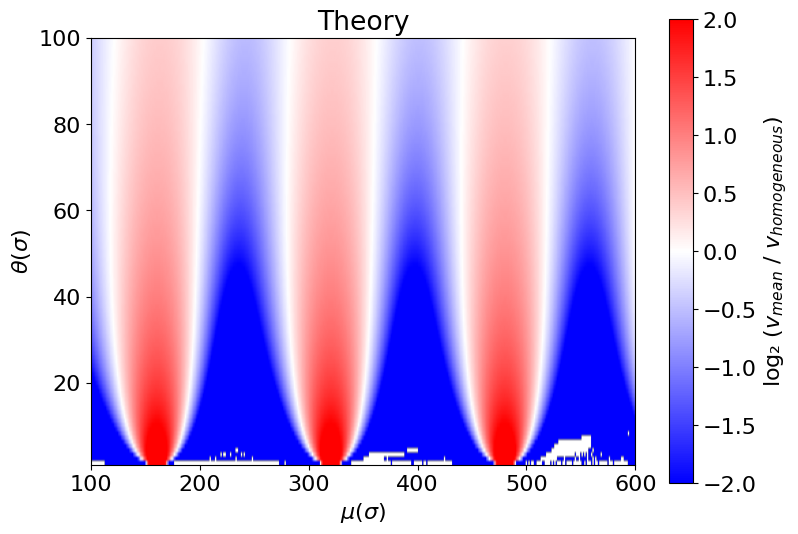

In [145]:
# Data from theory by Cesar
import numpy as np
import polars as pl
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 16


root = "/home/nicolas/Documents/Workspace/nucleo/outputs/THEORY/"
with open(root + "cesar_data.pkl", "rb") as f:
    data = pickle.load(f)


mu_vals = data["mu_vals"]
theta_vals = data["sigma_vals"]
v_theo = data["v_theo"]

alphaf, alphao = 1, 0
l, s = 10, 150

accessibility = (alphao * s + alphaf * l) / (s + l)
v_flat = mu_vals * 1 * accessibility
data_plot = np.log2(v_theo / v_flat)

data_plot = data_plot[:][0:101]
vmin, vmax = -2, 2
title_bar = r"log₂ ($ v_{mean}$ / $v_{homogeneous}$)"

plt.figure(figsize=(8, 6))
plt.title("Theory")
plt.imshow(
    data_plot,
    origin="lower",
    vmin=vmin, vmax=vmax,
    cmap="bwr",
    aspect='auto',
    extent=[mu_vals.min(), mu_vals.max(), theta_vals.min(), theta_vals[399]]
)
plt.gca().set_aspect(data_plot.shape[1] / data_plot.shape[0])
plt.xlabel("$\\mu(\\sigma)$")
plt.ylabel("$\\theta(\\sigma)$")
plt.tight_layout()
cbar = plt.colorbar()
cbar.set_label(title_bar)
plt.show()